# Natural disaster risk

Categorical hazard levels from **[GFDRR ThinkHazard!](https://thinkhazard.org)** (World Bank / GFDRR), fetched via its [public JSON API](https://gfdrr.github.io/thinkhazard/api/) at **ADM1 resolution** (states/provinces). Levels come as `Very Low` / `Low` / `Medium` / `High` / `No Data` per hazard type.

The pipeline seeds from the 245 ADM0 numeric IDs in `country_codes.json`, then fetches `report/{id}.geojson` per country — a single call returns the country polygon plus every ADM1 child polygon with its own numeric ID. Those ~3,600 ADM1 IDs are then used to fetch one hazard report each from `report/{id}.json`. Countries without ADM1 children (e.g. small island states) silently fall back to their ADM0 report.

Levels are encoded 0–3 (NaN for `no-data`); the three flood sub-types (`FL`/`UF`/`CF`) are aggregated into a single `flood` layer via max; the seven hazards that map to `common.NATURAL_DISASTER_DEFAULT_WEIGHTS` are kept. Polygons (in EPSG:3857 from ThinkHazard, reprojected to EPSG:4326) are rasterized onto the shared 0.5° atlas grid via `regionmask`.

The result is combined via `common.compute_natural_disaster_risk`, sign-inverted so higher = safer, and ocean cells are masked using `is_land` from `grid.nc`. Because most ADM1 divisions are larger than one 0.5° cell, values are still flat within a state — but the layer now resolves intra-country variation (🔴 Tier C in `DATASETS.md`, but a step up from flat ADM0).

In [1]:
import asyncio
import json
import re

import geopandas as gpd
import httpx
import numpy as np
import pandas as pd
import regionmask
import shapely
import xarray as xr
from tqdm.auto import tqdm

from common import (
    dominant_region_mask,
    normalize,
    RAW_DIR,
    weighted_score,
    load_grid,
    plot_map,
    save_variable,
)

VARIABLE = 'natural_disaster_risk'
variable_raw = RAW_DIR / VARIABLE
geojson_dir = variable_raw / 'geojson'
reports_dir = variable_raw / 'reports'
for d in (variable_raw, geojson_dir, reports_dir):
    d.mkdir(parents=True, exist_ok=True)

## 1. Fetch raw data

### 1a. ADM0 seed catalogue

We need a numeric ThinkHazard division ID per country, since the report endpoints only accept numeric IDs. On first run we bootstrap `country_codes.json` (ISO3 → numeric id) by fetching `divisions_flat.json` for the 245 ADM0 country names, then hitting the site's typeahead-search endpoint (`/en/administrativedivision?q=<name>`) to look up each numeric ID. Cached to disk; subsequent runs read from the cache.

In [2]:
codes_path = variable_raw / 'country_codes.json'
TYPEAHEAD_URL = 'https://thinkhazard.org/en/administrativedivision'
DIVISIONS_FLAT_URL = 'https://gfdrr.github.io/thinkhazard/divisions_flat.json'


def _strip_iso_suffix(name):
    """Drop a trailing ``' [ISO3]'`` suffix that appears in divisions_flat entries."""
    return re.sub(r'\s*\[[A-Z]{3}\]\s*$', '', name).strip()


async def _bootstrap_country_codes():
    """Build the ISO3 → numeric-id map by searching ThinkHazard's typeahead per country."""
    flat_path = variable_raw / 'divisions_flat.json'
    if not flat_path.exists():
        print(f'downloading {DIVISIONS_FLAT_URL}')
        r = httpx.get(DIVISIONS_FLAT_URL, timeout=120, follow_redirects=True)
        r.raise_for_status()
        flat_path.write_bytes(r.content)
    adm0 = [d for d in json.loads(flat_path.read_text())['divisions'] if d['level'] == 'ADM0']

    codes = {}
    sem = asyncio.Semaphore(CONCURRENCY := 10)
    async with httpx.AsyncClient(timeout=30) as client:
        pbar = tqdm(total=len(adm0), desc='seeding country IDs')

        async def lookup(entry):
            async with sem:
                query = _strip_iso_suffix(entry['name'])
                r = await client.get(TYPEAHEAD_URL, params={'q': query})
                for hit in r.json().get('data', []):
                    if hit.get('admin0') and not hit.get('admin1') and not hit.get('admin2'):
                        codes[entry['iso3']] = hit['code']
                        break
                pbar.update(1)

        await asyncio.gather(*(lookup(e) for e in adm0))
        pbar.close()
    return codes


if codes_path.exists():
    country_codes = json.loads(codes_path.read_text())
    print(f'loaded {len(country_codes)} cached country IDs from {codes_path.name}')
else:
    country_codes = await _bootstrap_country_codes()
    codes_path.write_text(json.dumps(country_codes, indent=2, sort_keys=True))
    print(f'wrote {codes_path} with {len(country_codes)} entries')

country_ids = sorted(set(country_codes.values()))
print(f'{len(country_ids)} unique country IDs')

loaded 232 cached country IDs from country_codes.json
232 unique country IDs


### 1b. Fetch country geojsons

Each `report/{id}.geojson` returns a `FeatureCollection` with the country polygon plus every ADM1 child polygon, in EPSG:3857 (Web Mercator). Cached under `raw/natural_disaster_risk/geojson/{id}.geojson` — subsequent runs skip anything already on disk.

In [3]:
BASE = 'https://thinkhazard.org/en/report'
CONCURRENCY = 10


async def fetch_many(url_paths, desc):
    """Concurrently GET (url, cache_path) pairs; skip pairs whose cache_path already exists.

    Parameters
    ----------
    url_paths : list[tuple[str, pathlib.Path]]
        Pairs of URL to fetch and local path to cache the response body under.
    desc : str
        tqdm progress-bar label.
    """
    todo = [(u, p) for u, p in url_paths if not p.exists()]
    if not todo:
        print(f'{desc}: all {len(url_paths)} cached')
        return
    sem = asyncio.Semaphore(CONCURRENCY)
    async with httpx.AsyncClient(timeout=60) as client:
        pbar = tqdm(total=len(todo), desc=desc)

        async def one(url, path):
            async with sem:
                r = await client.get(url)
                r.raise_for_status()
                path.write_text(r.text)
                pbar.update(1)

        await asyncio.gather(*(one(u, p) for u, p in todo))
        pbar.close()


await fetch_many(
    [(f'{BASE}/{cid}.geojson', geojson_dir / f'{cid}.geojson') for cid in country_ids],
    desc='country geojsons',
)
print(f'{len(list(geojson_dir.glob("*.geojson")))} geojsons cached')

country geojsons: all 232 cached
232 geojsons cached


### 1c. Parse geojsons → division catalogue

For each cached country bundle, every feature's `properties.code` is the numeric ID. The country row (matching the seed ID) is ADM0; the rest are ADM1. Polygons are reprojected from Web Mercator to WGS84 for the rasterization step.

In [4]:
rows = []
skipped = 0
for cid in country_ids:
    fc = json.loads((geojson_dir / f'{cid}.geojson').read_text())
    for feat in fc['features']:
        if feat.get('geometry') is None:
            skipped += 1
            continue
        props = feat['properties']
        div_id = int(props['code'])
        rows.append({
            'id': div_id,
            'name': props['name'],
            'country_id': cid,
            'level': 'ADM0' if div_id == cid else 'ADM1',
            'geometry': shapely.geometry.shape(feat['geometry']),
        })

divisions_gdf = (
    gpd.GeoDataFrame(rows, geometry='geometry', crs='EPSG:3857')
    .drop_duplicates(subset='id', keep='first')
    .set_index('id')
    .to_crs('EPSG:4326')
)

print(f'{skipped} features skipped (null geometry)')
print(divisions_gdf['level'].value_counts())
divisions_gdf.head()

14 features skipped (null geometry)
level
ADM1    3138
ADM0     232
Name: count, dtype: int64


,name,country_id,level,geometry
id,,,,
1,Afghanistan,1,ADM0,"MULTIPOLYGON (((70.99956 38.47933, 71.05621 38..."
281,Hilmand,1,ADM1,"MULTIPOLYGON (((65.62134 33.67257, 65.6849 33...."
283,Jawzjan,1,ADM1,"MULTIPOLYGON (((65.76406 37.53674, 65.83961 37..."
99880,Parwan,1,ADM1,"MULTIPOLYGON (((69.19299 35.42047, 69.25015 35..."
272,Badakhshan,1,ADM1,"MULTIPOLYGON (((71.00345 38.47583, 71.05621 38..."


### 1d. Fetch hazard reports

Fetch one report per ADM1 division (~3,600 files). For countries without ADM1 children, fetch the ADM0 report as a silent fallback so the country still gets a value. On first run, migrate any legacy ISO3-named report files (e.g. `DEU.json`) to their numeric-ID form (`93.json`).

In [5]:
# Migrate legacy ISO3-named report files to numeric-ID form (one-time)
for iso3, num_id in country_codes.items():
    legacy = reports_dir / f'{iso3}.json'
    numeric = reports_dir / f'{num_id}.json'
    if legacy.exists() and not numeric.exists():
        legacy.rename(numeric)

# ADM1s from the crawl + ADM0 fallbacks for countries with no ADM1 children
countries_with_adm1 = set(divisions_gdf.loc[divisions_gdf['level'] == 'ADM1', 'country_id'])
adm0_fallbacks = [c for c in country_ids if c not in countries_with_adm1]
adm1_ids = divisions_gdf.index[divisions_gdf['level'] == 'ADM1'].tolist()
report_ids = sorted(set(adm1_ids) | set(adm0_fallbacks))
print(f'{len(adm1_ids)} ADM1s + {len(adm0_fallbacks)} ADM0 fallbacks = {len(report_ids)} reports to ensure')

await fetch_many(
    [(f'{BASE}/{rid}.json', reports_dir / f'{rid}.json') for rid in report_ids],
    desc='hazard reports',
)
print(f'{len(list(reports_dir.glob("*.json")))} report files cached')

3138 ADM1s + 0 ADM0 fallbacks = 3138 reports to ensure
hazard reports: all 3138 cached
3138 report files cached


## 2. Parse reports → per-division hazard table

Encode `VLO`/`LOW`/`MED`/`HIG` as 0–3 and `no-data` as NaN. Aggregate the three flood sub-types (`FL`/`UF`/`CF`) into a single `flood` column via max — a region flags as flood-prone if any sub-type is high. Keep only the seven hazards in `NATURAL_DISASTER_DEFAULT_WEIGHTS`.

In [6]:
LEVEL_MAP = {'VLO': 0.0, 'LOW': 1.0, 'MED': 2.0, 'HIG': 3.0, 'no-data': np.nan}
HAZARD_COLS = {
    'EQ': 'earthquake',
    'CY': 'cyclone',
    'WF': 'wildfire',
    'LS': 'landslide',
    'DG': 'drought',
    'VA': 'volcano',
}
FLOOD_SUBTYPES = ('FL', 'UF', 'CF')


def parse_report(path):
    """Parse one cached ThinkHazard report file into a hazard-name -> score dict.

    Levels map to 0-3 via ``LEVEL_MAP`` (``no-data`` becomes NaN). The three
    flood sub-types (``FL`` river, ``UF`` urban, ``CF`` coastal) collapse to a
    single ``flood`` key via ``np.nanmax``. Hazards not listed in ``HAZARD_COLS``
    are dropped.
    """
    entries = json.loads(path.read_text())
    raw = {e['hazardtype']['mnemonic']: LEVEL_MAP[e['hazardlevel']['mnemonic']] for e in entries}
    out = {name: raw.get(m, np.nan) for m, name in HAZARD_COLS.items()}
    flood_vals = [raw[m] for m in FLOOD_SUBTYPES if m in raw and not np.isnan(raw[m])]
    out['flood'] = float(np.nanmax(flood_vals)) if flood_vals else np.nan
    return out


hazards_df = pd.DataFrame(
    {int(p.stem): parse_report(p) for p in sorted(reports_dir.glob('*.json'))}
).T
hazards_df.index.name = 'id'

# ADM1 rows without their own report fall back to the parent country's row
for adm1_id, row in divisions_gdf[divisions_gdf['level'] == 'ADM1'].iterrows():
    if adm1_id not in hazards_df.index and row['country_id'] in hazards_df.index:
        hazards_df.loc[adm1_id] = hazards_df.loc[row['country_id']]

print(f'{len(hazards_df)} rows in hazards_df')
hazards_df.head()

3138 rows in hazards_df


,earthquake,cyclone,wildfire,landslide,drought,volcano,flood
id,,,,,,,
1000,2.0,NaN,3.0,2.0,0.0,NaN,2.0
1001,2.0,NaN,3.0,1.0,1.0,NaN,3.0
1002,2.0,NaN,3.0,1.0,1.0,NaN,3.0
1003,2.0,NaN,3.0,0.0,0.0,NaN,3.0
1004,2.0,NaN,3.0,2.0,1.0,NaN,3.0


## 3. Rasterize onto the 0.5° grid

For each grid cell, pick the smallest containing division: ADM1 where a country has any ADM1 hazard data, ADM0 otherwise. `regionmask` returns an integer index per cell; a numpy lookup then maps that index to each hazard's value.

In [7]:
grid = load_grid()

# Attach hazards to polygons; drop divisions with no matching hazard row
usable = divisions_gdf.join(hazards_df, how='inner').copy()

# Prefer ADM1 where possible; keep ADM0 only for countries with no ADM1 in usable
adm1_countries = set(usable.loc[usable['level'] == 'ADM1', 'country_id'])
usable = usable[
    (usable['level'] == 'ADM1') | ~usable['country_id'].isin(adm1_countries)
].reset_index(drop=True)

print(f'{len(usable)} regions to rasterize '
      f'({(usable["level"] == "ADM1").sum()} ADM1 + '
      f'{(usable["level"] == "ADM0").sum()} ADM0 fallback)')

# ADM1 polygons within a country tile cleanly, but adjacent-country borders
# and disputed regions produce minor overlaps. `overlap=False` tells regionmask
# to skip the check and let the first matching polygon win — good enough at 0.5°.
# dominant_region_mask assigns each cell to the region with the largest fractional
# coverage, so island cells whose centre sits in the ocean still pick up their
# ADM1 (or ADM0 fallback) instead of dropping to NaN.
regions = regionmask.from_geopandas(usable, overlap=False)
region_idx = dominant_region_mask(regions, grid.lon, grid.lat)

idx_arr = region_idx.values
valid = ~np.isnan(idx_arr)
idx_int = np.where(valid, idx_arr, 0).astype(int)

hazards = {}
for name in ('earthquake', 'cyclone', 'flood', 'wildfire', 'landslide', 'drought', 'volcano'):
    lookup = usable[name].to_numpy(dtype='float32')
    raster = np.where(valid, lookup[idx_int], np.nan).astype('float32')
    hazards[name] = xr.DataArray(
        raster, coords={'lat': grid.lat, 'lon': grid.lon}, dims=('lat', 'lon'), name=name,
    )

hazards_ds = xr.Dataset(hazards)
hazards_ds

3138 regions to rasterize (3138 ADM1 + 0 ADM0 fallback)


<xarray.Dataset> Size: 7MB
Dimensions:     (lat: 360, lon: 720)
Coordinates:
  * lat         (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon         (lon) float64 6kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
Data variables:
    earthquake  (lat, lon) float32 1MB nan nan nan nan nan ... nan nan nan nan
    cyclone     (lat, lon) float32 1MB nan nan nan nan nan ... nan nan nan nan
    flood       (lat, lon) float32 1MB nan nan nan nan nan ... nan nan nan nan
    wildfire    (lat, lon) float32 1MB nan nan nan nan nan ... nan nan nan nan
    landslide   (lat, lon) float32 1MB nan nan nan nan nan ... nan nan nan nan
    drought     (lat, lon) float32 1MB nan nan nan nan nan ... nan nan nan nan
    volcano     (lat, lon) float32 1MB nan nan nan nan nan ... nan nan nan nan

## 4. Cache intermediate

Save the per-hazard stack so `compute_natural_disaster_risk` can be called later (e.g. from a Dash app or scoring notebook) with custom weights, without re-crawling.

In [8]:
# cache_path = PROCESSED_DIR / '_hazards_by_type.nc'
# if cache_path.exists():
#     cache_path.unlink()
# hazards_ds.to_netcdf(cache_path)
# print(f'wrote {cache_path}')

In [9]:
NATURAL_DISASTER_DEFAULT_WEIGHTS = {
    'earthquake': 1.0,
    'cyclone':    1.0,
    'flood':      1.0,
    'wildfire':   0.5,
    'landslide':  0.5,
    'drought':    0.7,
    'volcano':    0.3,
}


def compute_natural_disaster_risk(ds, weights=NATURAL_DISASTER_DEFAULT_WEIGHTS):
    """Weighted average of per-hazard risk layers.

    Reads the intermediate ``processed/_hazards_by_type.nc`` (produced by
    ``18_natural_disaster_risk.ipynb``), min-max normalizes each hazard layer
    to ``[0, 1]``, then computes a weighted average across hazards. Hazards
    listed in ``weights`` but absent from the file are silently skipped so
    partial hazard sets still score.

    Separated from the notebook so re-scoring with different preferences (an
    interactive UI, a Dash app, a parameter sweep) does not need the notebook
    or a re-fetch of the source data.

    Parameters
    ----------
    source : pathlib.Path
        Path to the intermediate NetCDF Dataset with one variable per hazard.
    weights : dict[str, float], optional
        Hazard name -> weight. Defaults to
        :data:`NATURAL_DISASTER_DEFAULT_WEIGHTS`.

    Returns
    -------
    xarray.DataArray
        2D ``(lat, lon)`` risk score in ``[0, 1]`` — higher = more risk.
        Sign inversion is the caller's responsibility.
    """
    active = {h: w for h, w in weights.items() if h in ds.data_vars}
    if not active:
        raise ValueError(f"none of {list(weights)} present in {source}")

    # Per-cell weight renormalization so a NaN in one hazard doesn't wipe the
    # cell — the remaining hazards' weights are simply rescaled. Mirrors
    # `weighted_score`, which the atlas uses at the top-level score stage.
    layers = {h: normalize(ds[h]) for h in active}
    return weighted_score(layers, active)


## 5. Combine, sign-invert, and mask

Normalize each hazard to `[0, 1]`, apply `NATURAL_DISASTER_DEFAULT_WEIGHTS` (earthquake / cyclone / flood at 1.0, wildfire / landslide at 0.5, drought at 0.7, volcano at 0.3), invert the sign so higher = safer (atlas convention), and mask ocean cells.

In [10]:
risk = compute_natural_disaster_risk(hazards_ds)
values = (-risk).astype('float32').rename(VARIABLE).where(grid.is_land == 1)
values

<xarray.DataArray 'natural_disaster_risk' (lat: 360, lon: 720)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(360, 720), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

## 6. Plot

<Axes: title={'center': 'natural_disaster_risk'}, xlabel='longitude', ylabel='latitude'>

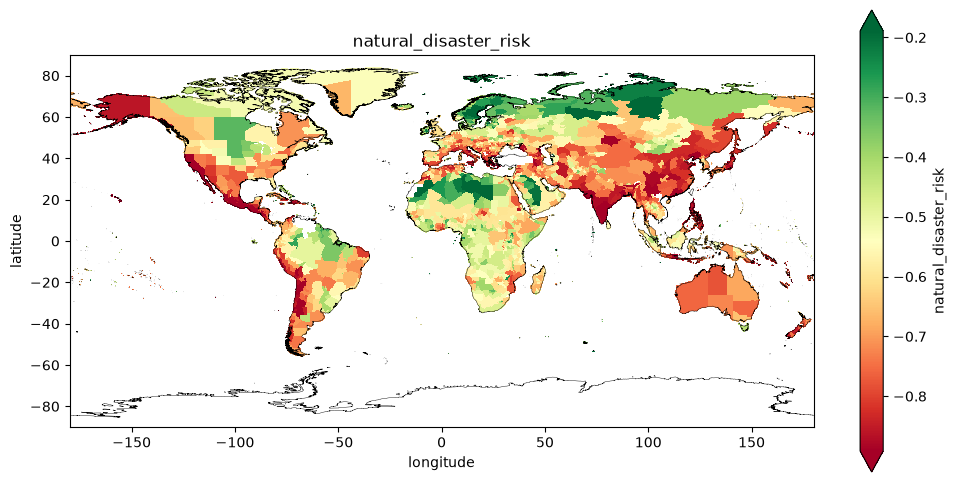

In [11]:
plot_map(values, cmap='RdYlGn', robust=True)

## 7. Save

In [12]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/natural_disaster_risk.nc
